# Statistical foundations of machine learning project group (19)

Link for the video presentation: https://universitelibrebruxelles.sharepoint.com/:v:/s/GRP_stat261/EdpB4jX8FElPhNE_3DWDwQcBOvicoGrRdVMlPoUpbX_rtA?e=aImeDu

Team members:
- Thomas Vray
- Nicolas Blanquez-Yeste
- Wassim Al Khouri

## 1. Read data 

### 1.1 Import libraries

In [1]:
#install.packages("fastDummies")
#install.packages("keras")
#install.packages("tensorflow")
#install.packages("e1071")
#install.packages("randomForest")
#install.packages("xgboost")
#install.packages("tidymodels")

library(fastDummies)
library(keras)
library(tensorflow)
library(e1071)
library(randomForest)
library(xgboost)
library(tidymodels)

Thank you for using fastDummies!

To acknowledge our work, please cite the package:

Kaplan, J. & Schlegel, B. (2023). fastDummies: Fast Creation of Dummy (Binary) Columns and Rows from Categorical Variables. Version 1.7.1. URL: https://github.com/jacobkap/fastDummies, https://jacobkap.github.io/fastDummies/.

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.5      ✔ recipes      1.0.10
✔ dials        1.2.1      ✔ rsample      1.2.1 
✔ dplyr        1.1.4      ✔ tibble       3.2.1 
✔ ggplot2      3.5.1      ✔ tidyr        1.3.1 
✔ infer        1.0.7      ✔ tune         1.2.1 
✔ modeldata    1.3.0      ✔ workflows    1.1.4 
✔ parsnip      1.2.1      ✔ workflowsets 1.1.0 
✔ purrr        1.0.2      ✔ yardstick    1.3.1 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ dplyr::combine()         masks randomForest::combine()
✖ purrr

### 1.2 Load data

In [2]:
data<-read.csv("Train.csv", header = TRUE)
set.seed(2)

### 1.3 Preprocessing

For preprocessing the data we remove the columns that contain a lot of missing values. We also remove the date and place_id columns as the date is not relevant for the prediction and the place_ids in the train and test data are different. Tests were made where the date and place ids were included but they had a negative impact on the model performance. 

We also tried removing rows with a lot of missing values but that also had a negative impact on the model performance. This is because even though some variables are missing, it still contains valuable information.

In [3]:
replace_na_with_mean_value<-function(vec) {
    mean_vec<-mean(vec,na.rm=T)
    vec[is.na(vec)]<-mean_vec
    vec
}

In [4]:
countnaCol <- colSums(is.na(data))
countnaCol <- countnaCol[countnaCol/dim(data[1])[1] > 0.7]

#countnaRow <- rowSums(is.na(data))
#countnaRow <- countnaRow[countnaRow/dim(data)[2] > 0.5]

data <- data[, -which(names(data) %in% names(countnaCol))]
#data <- data[-which(countnaRow > 0),]

factor_variables <- c(which(sapply(data[1,], class) == "character"))

#data <- dummy_cols(data, select_columns = c("Place_ID"))
data <- data[,-factor_variables]


data<-data.frame(apply(data,2,replace_na_with_mean_value))

X <- data %>% select(-c("target","target_min","target_max","target_variance","target_count"))
Y <- data %>% select(c("target"))
dim(X)

[1] 30557    67

## 2. Feature Selection

For feature selection, we will use the following techniques:
- **Correlation Matrix-based**
- **minimal-redundancy-maximal-relevance** (mRMR) 
- **Forward Selection** (Not used in this notebook)

After ranking the features, we loop through them and train a model to see how well it performs. The number of features that produces the least error is selected. The XGBoost model was used because it is a powerful and fast model.

### 2.1. Correlation

In [5]:
correlation_vector <-abs(cor(X,Y))

correlation_ranking_idx <-sort(correlation_vector,dec=T,index.return=T)$ix

X_corr <- X[,correlation_ranking_idx]

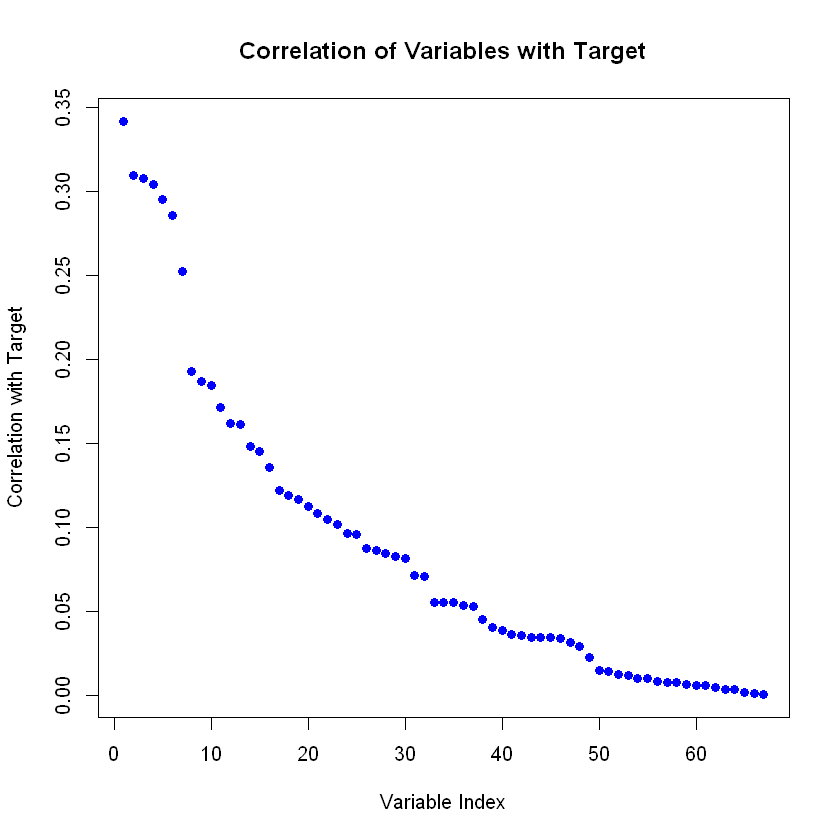

In [6]:
plot(correlation_vector[correlation_ranking_idx],type="p",pch=19,col="blue",xlab="Variable Index",ylab="Correlation with Target",main="Correlation of Variables with Target")

In [7]:
# This code is taken from the practicals
N <- nrow(X)

nFeatures <- ncol(X_corr)

CV_folds <- 5
size_CV <- floor(N/CV_folds)
CV_err_features_corr <- matrix(0, nrow = 1, ncol = nFeatures)

best_nrounds <- 50
best_eta <- 0.2
best_max_depth <- 7
best_min_child_weight <- 1.5

for (n in 2:nFeatures) {
  fold_errors <- numeric(CV_folds)
  X_fold <- X_corr[,1:n]
  for (i in 1:CV_folds) {
    idx_ts <- (((i-1)*size_CV+1):(i*size_CV))
    X_ts <- X_fold[idx_ts,]
    Y_ts <- Y[idx_ts,]
    
    idx_tr <- setdiff(1:N, idx_ts)
    X_tr <- X_fold[idx_tr,]
    Y_tr <- Y[idx_tr,]

    params <- list(
            booster = "gbtree",
            objective = "reg:squarederror",
            eta = best_eta,
            max_depth = best_max_depth,
            min_child_weight = best_min_child_weight
          )

    dtrain <- xgb.DMatrix(data = as.matrix(X_tr), label = as.matrix(Y_tr))
    dtest <- xgb.DMatrix(data = as.matrix(X_ts), label = as.matrix(Y_ts))

    model <- xgb.train(
      params = params,
      data = dtrain,
      nrounds = best_nrounds,
      watchlist = list(train = dtrain, test = dtest),
      early_stopping_rounds = 5,
      verbose = 0
    )

    Y_hat_ts <- predict(model, as.matrix(X_ts))
    
    fold_errors[i] <- sqrt(mean((Y_hat_ts - Y_ts)^2))
  }
  CV_err_features_corr[1,n] <- mean(fold_errors)
}

print(CV_err_features_corr)

     [,1]     [,2]     [,3]     [,4]     [,5]     [,6]     [,7]     [,8]
[1,]    0 41.76266 39.83595 37.93043 37.96252 37.89922 37.75025 37.64812
         [,9]    [,10]    [,11]    [,12]    [,13]    [,14]    [,15]    [,16]
[1,] 37.54913 37.68632 37.55205 37.60817 37.54968 37.01977 36.94569 36.90729
        [,17]    [,18]    [,19]    [,20]    [,21]    [,22]    [,23]    [,24]
[1,] 36.55043 36.52263 36.37292 36.01214 35.99867 35.92631 35.58861 35.75102
       [,25]    [,26]    [,27]    [,28]    [,29]    [,30]    [,31]    [,32]
[1,] 35.6975 35.67923 35.54304 35.61835 35.36085 35.09616 35.20951 35.08819
        [,33]   [,34]    [,35]    [,36]    [,37]    [,38]    [,39]    [,40]
[1,] 34.98791 35.0159 34.46137 34.40864 34.56919 34.48787 34.48912 34.27058
      [,41]    [,42]    [,43]    [,44]    [,45]    [,46]    [,47]    [,48]
[1,] 34.088 34.30984 34.16286 34.16999 33.96592 33.98529 34.01645 34.02921
        [,49]    [,50]   [,51]    [,52]    [,53]    [,54]    [,55]   [,56]
[1,] 34.06563 34.

In [8]:
CV_err_features_corr[1,1] <- 10000
best_number_of_features_corr <- which.min(CV_err_features_corr)
best_number_of_features_corr

X_corr <- X_corr[,1:best_number_of_features_corr]
colnames(X_corr)

[1] 51

[1] "L3_CO_CO_column_number_density"                     
 [2] "L3_HCHO_tropospheric_HCHO_column_number_density"    
 [3] "L3_AER_AI_sensor_altitude"                          
 [4] "L3_NO2_NO2_slant_column_number_density"             
 [5] "L3_NO2_NO2_column_number_density"                   
 [6] "L3_HCHO_HCHO_slant_column_number_density"           
 [7] "L3_NO2_tropospheric_NO2_column_number_density"      
 [8] "L3_AER_AI_solar_azimuth_angle"                      
 [9] "L3_CLOUD_solar_azimuth_angle"                       
[10] "L3_O3_solar_azimuth_angle"                          
[11] "L3_NO2_solar_azimuth_angle"                         
[12] "L3_HCHO_solar_azimuth_angle"                        
[13] "L3_SO2_solar_azimuth_angle"                         
[14] "u_component_of_wind_10m_above_ground"               
[15] "L3_CO_solar_azimuth_angle"                          
[16] "L3_SO2_absorbing_aerosol_index"                     
[17] "L3_CLOUD_cloud_top_pressure"                        
[18] "L3_NO2_cloud_fraction"                              
[19] "L3_CLOUD_cloud_optical_depth"                       
[20] "L3_CLOUD_cloud_fraction"                            
[21] "L3_O3_cloud_fraction"                               
[22] "L3_CLOUD_cloud_top_height"                          
[23] "L3_HCHO_tropospheric_HCHO_column_number_density_amf"
[24] "L3_CO_cloud_height"                                 
[25] "L3_CLOUD_cloud_base_pressure"                       
[26] "L3_O3_O3_column_number_density"                     
[27] "L3_CLOUD_cloud_base_height"                         
[28] "relative_humidity_2m_above_ground"                  
[29] "L3_AER_AI_solar_zenith_angle"                       
[30] "L3_NO2_tropopause_pressure"                         
[31] "L3_CLOUD_solar_zenith_angle"                        
[32] "L3_AER_AI_absorbing_aerosol_index"                  
[33] "L3_O3_solar_zenith_angle"                           
[34] "L3_NO2_sensor_altitude"                             
[35] "v_component_of_wind_10m_above_ground"               
[36] "L3_SO2_SO2_slant_column_number_density"             
[37] "L3_CLOUD_surface_albedo"                            
[38] "L3_CO_solar_zenith_angle"                           
[39] "L3_SO2_SO2_column_number_density"                   
[40] "temperature_2m_above_ground"                        
[41] "L3_NO2_sensor_zenith_angle"                         
[42] "specific_humidity_2m_above_ground"                  
[43] "L3_HCHO_solar_zenith_angle"                         
[44] "L3_NO2_stratospheric_NO2_column_number_density"     
[45] "L3_O3_O3_effective_temperature"                     
[46] "L3_SO2_solar_zenith_angle"                          
[47] "precipitable_water_entire_atmosphere"               
[48] "L3_NO2_absorbing_aerosol_index"                     
[49] "L3_SO2_cloud_fraction"                              
[50] "L3_SO2_sensor_azimuth_angle"                        
[51] "L3_SO2_SO2_column_number_density_amf"

### 2.2. mRMR

In [9]:
# This code is taken from the practicals
n <- ncol(X)

mutual_info <- -0.5 * log(1 - cor(X,Y)^2)

selected<-c()
candidates<-1:n
mRMR_scores<-numeric(n)

for (j in 1:n) {
    redundancy_score<-numeric(length(candidates))

    if (length(selected)>0) {
        mutual_info_selected_candidates <- -0.5 * log(1 - cor(X[,selected,drop=F],X[,candidates,drop=F])^2)
        redundancy_score<-apply(mutual_info_selected_candidates,2,mean)
    }

    mRMR_score<-mutual_info[candidates]-redundancy_score

    candidate_index<-which.max(mRMR_score)
    mRMR_scores[j]<-mRMR_score[candidate_index]
    selected_current<-candidates[candidate_index]
    selected<-c(selected,selected_current)

    candidates<-setdiff(candidates,selected_current)
}

mRMR_selected_variables<-selected
mRMR_selected_variables

[1] 26  8 40 54 62  5 45 59 47 30 14  2  6  7 41 28 23 52 19 34 38 10 27 16 53
[26] 18 60 35 32 29 61 58 36 57  1  9 13 20 44 17 12 37 42 66 67 11 63  4 55 24
[51] 31  3 21 33 64 56 15 43 50 65 39 22 25 46 49 51 48

In [10]:
X_mRMR <- X[,mRMR_selected_variables]

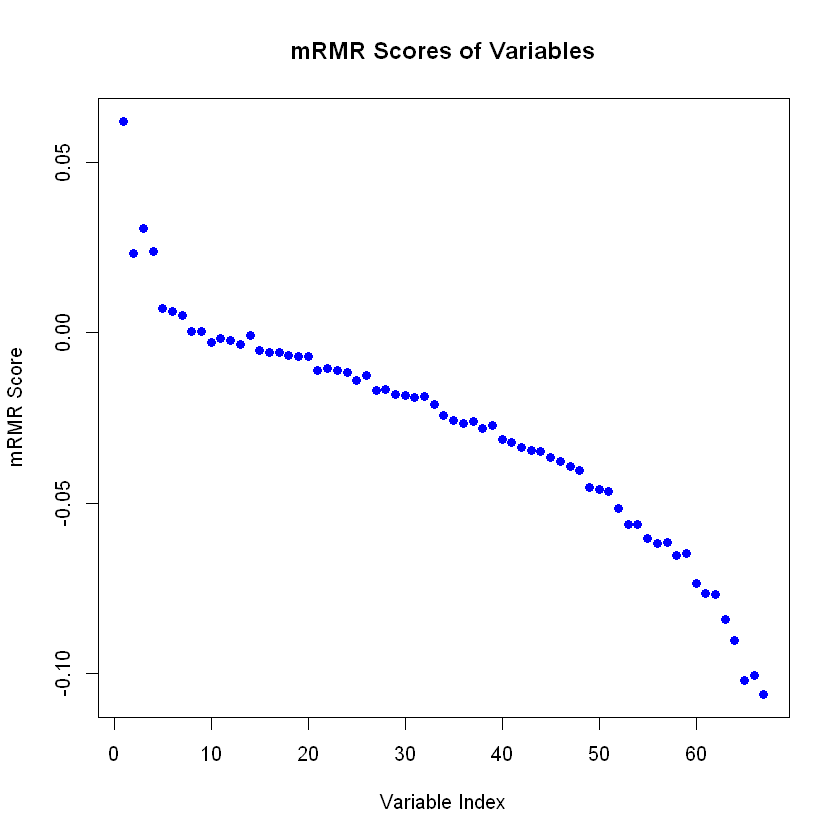

In [11]:
plot(mRMR_scores,type="p",pch=19,col="blue",xlab="Variable Index",ylab="mRMR Score",main="mRMR Scores of Variables")

In [12]:
n <- ncol(X_mRMR)
N <- nrow(X_mRMR)

nfeatures <- length(mRMR_selected_variables)

CV_folds <- 5
size_CV <- floor(N/CV_folds)
CV_err_features_mRMR <- matrix(0, nrow = 1, ncol = nfeatures)

for (nf in 2:nfeatures) {
  fold_errors <- numeric(CV_folds)
  X_fold <- X_mRMR[,1:nf]
  for (i in 1:CV_folds) {
    idx_ts <- (((i-1)*size_CV+1):(i*size_CV))
    X_ts <- X_fold[idx_ts,]
    Y_ts <- Y[idx_ts,]
    
    idx_tr <- setdiff(1:N, idx_ts)
    X_tr <- X_fold[idx_tr,]
    Y_tr <- Y[idx_tr,]
    
    params <- list(
            booster = "gbtree",
            objective = "reg:squarederror",
            eta = best_eta,
            max_depth = best_max_depth,
            min_child_weight = best_min_child_weight
          )

    dtrain <- xgb.DMatrix(data = as.matrix(X_tr), label = as.matrix(Y_tr))
    dtest <- xgb.DMatrix(data = as.matrix(X_ts), label = as.matrix(Y_ts))

    model <- xgb.train(
      params = params,
      data = dtrain,
      nrounds = best_nrounds,
      watchlist = list(train = dtrain, test = dtest),
      early_stopping_rounds = 5,
      verbose = 0
    )
    
    Y_hat_ts <- predict(model, as.matrix(X_ts))

    fold_errors[i] <- sqrt(mean((Y_hat_ts - Y_ts)^2))
  }
  CV_err_features_mRMR[1, nf] <- mean(fold_errors)
}

print(CV_err_features_mRMR)

     [,1]     [,2]     [,3]     [,4]     [,5]     [,6]     [,7]     [,8]
[1,]    0 41.38987 39.70309 37.93028 37.79592 37.12864 36.68769 36.84384
         [,9]    [,10]    [,11]    [,12]    [,13]    [,14]    [,15]    [,16]
[1,] 36.60049 36.58239 36.47058 36.19894 35.54972 35.58723 35.39518 35.26258
        [,17]    [,18]    [,19]    [,20]    [,21]    [,22]    [,23]    [,24]
[1,] 35.14097 35.05199 35.05283 35.10756 35.24532 35.21983 34.86541 34.99269
        [,25]    [,26]    [,27]    [,28]    [,29]   [,30]   [,31]    [,32]
[1,] 34.79574 34.66394 34.58752 34.50688 34.47628 34.4817 34.3969 34.26613
        [,33]    [,34]    [,35]    [,36]    [,37]    [,38]    [,39]    [,40]
[1,] 34.27094 34.27534 34.30403 34.15923 34.20242 34.37831 34.30276 34.05389
        [,41]    [,42]    [,43]    [,44]    [,45]    [,46]    [,47]    [,48]
[1,] 34.16612 34.03368 34.21488 34.04249 34.13113 34.05871 34.09334 34.09417
        [,49]    [,50]    [,51]    [,52]    [,53]    [,54]    [,55]    [,56]
[1,] 34.053

In [13]:
CV_err_features_mRMR[1,1] <- 1000
best_number_of_features_mRMR <- which.min(CV_err_features_mRMR)
best_number_of_features_mRMR
X_mRMR <- X_mRMR[,1:best_number_of_features_mRMR]
colnames(X_mRMR)

[1] 63

[1] "L3_CO_CO_column_number_density"                     
 [2] "L3_NO2_NO2_slant_column_number_density"             
 [3] "L3_HCHO_tropospheric_HCHO_column_number_density"    
 [4] "L3_AER_AI_sensor_altitude"                          
 [5] "L3_SO2_absorbing_aerosol_index"                     
 [6] "u_component_of_wind_10m_above_ground"               
 [7] "L3_CLOUD_cloud_optical_depth"                       
 [8] "L3_SO2_SO2_column_number_density"                   
 [9] "L3_CLOUD_cloud_top_pressure"                        
[10] "L3_CO_sensor_azimuth_angle"                         
[11] "L3_NO2_solar_azimuth_angle"                         
[12] "relative_humidity_2m_above_ground"                  
[13] "v_component_of_wind_10m_above_ground"               
[14] "L3_NO2_NO2_column_number_density"                   
[15] "L3_HCHO_tropospheric_HCHO_column_number_density_amf"
[16] "L3_CO_cloud_height"                                 
[17] "L3_O3_sensor_zenith_angle"                          
[18] "L3_CLOUD_surface_albedo"                            
[19] "L3_O3_O3_column_number_density"                     
[20] "L3_HCHO_HCHO_slant_column_number_density"           
[21] "L3_HCHO_solar_azimuth_angle"                        
[22] "L3_NO2_cloud_fraction"                              
[23] "L3_CO_H2O_column_number_density"                    
[24] "L3_NO2_stratospheric_NO2_column_number_density"     
[25] "L3_AER_AI_absorbing_aerosol_index"                  
[26] "L3_NO2_tropospheric_NO2_column_number_density"      
[27] "L3_SO2_SO2_column_number_density_amf"               
[28] "L3_HCHO_cloud_fraction"                             
[29] "L3_CO_solar_azimuth_angle"                          
[30] "L3_CO_sensor_altitude"                              
[31] "L3_SO2_SO2_slant_column_number_density"             
[32] "L3_AER_AI_solar_zenith_angle"                       
[33] "L3_HCHO_sensor_azimuth_angle"                       
[34] "L3_AER_AI_solar_azimuth_angle"                      
[35] "precipitable_water_entire_atmosphere"               
[36] "L3_NO2_absorbing_aerosol_index"                     
[37] "L3_NO2_sensor_zenith_angle"                         
[38] "L3_O3_O3_effective_temperature"                     
[39] "L3_CLOUD_cloud_fraction"                            
[40] "L3_NO2_tropopause_pressure"                         
[41] "L3_NO2_sensor_azimuth_angle"                        
[42] "L3_HCHO_sensor_zenith_angle"                        
[43] "L3_CLOUD_cloud_base_height"                         
[44] "L3_SO2_solar_azimuth_angle"                         
[45] "L3_SO2_solar_zenith_angle"                          
[46] "L3_NO2_sensor_altitude"                             
[47] "L3_SO2_cloud_fraction"                              
[48] "temperature_2m_above_ground"                        
[49] "L3_AER_AI_sensor_azimuth_angle"                     
[50] "L3_O3_solar_azimuth_angle"                          
[51] "L3_CO_sensor_zenith_angle"                          
[52] "specific_humidity_2m_above_ground"                  
[53] "L3_O3_cloud_fraction"                               
[54] "L3_CO_solar_zenith_angle"                           
[55] "L3_SO2_sensor_azimuth_angle"                        
[56] "L3_AER_AI_sensor_zenith_angle"                      
[57] "L3_NO2_solar_zenith_angle"                          
[58] "L3_CLOUD_cloud_base_pressure"                       
[59] "L3_CLOUD_solar_azimuth_angle"                       
[60] "L3_SO2_sensor_zenith_angle"                         
[61] "L3_HCHO_solar_zenith_angle"                         
[62] "L3_O3_sensor_azimuth_angle"                         
[63] "L3_O3_solar_zenith_angle"

In [14]:
colnames(X_corr)
colnames(X_mRMR)

[1] "L3_CO_CO_column_number_density"                     
 [2] "L3_HCHO_tropospheric_HCHO_column_number_density"    
 [3] "L3_AER_AI_sensor_altitude"                          
 [4] "L3_NO2_NO2_slant_column_number_density"             
 [5] "L3_NO2_NO2_column_number_density"                   
 [6] "L3_HCHO_HCHO_slant_column_number_density"           
 [7] "L3_NO2_tropospheric_NO2_column_number_density"      
 [8] "L3_AER_AI_solar_azimuth_angle"                      
 [9] "L3_CLOUD_solar_azimuth_angle"                       
[10] "L3_O3_solar_azimuth_angle"                          
[11] "L3_NO2_solar_azimuth_angle"                         
[12] "L3_HCHO_solar_azimuth_angle"                        
[13] "L3_SO2_solar_azimuth_angle"                         
[14] "u_component_of_wind_10m_above_ground"               
[15] "L3_CO_solar_azimuth_angle"                          
[16] "L3_SO2_absorbing_aerosol_index"                     
[17] "L3_CLOUD_cloud_top_pressure"                        
[18] "L3_NO2_cloud_fraction"                              
[19] "L3_CLOUD_cloud_optical_depth"                       
[20] "L3_CLOUD_cloud_fraction"                            
[21] "L3_O3_cloud_fraction"                               
[22] "L3_CLOUD_cloud_top_height"                          
[23] "L3_HCHO_tropospheric_HCHO_column_number_density_amf"
[24] "L3_CO_cloud_height"                                 
[25] "L3_CLOUD_cloud_base_pressure"                       
[26] "L3_O3_O3_column_number_density"                     
[27] "L3_CLOUD_cloud_base_height"                         
[28] "relative_humidity_2m_above_ground"                  
[29] "L3_AER_AI_solar_zenith_angle"                       
[30] "L3_NO2_tropopause_pressure"                         
[31] "L3_CLOUD_solar_zenith_angle"                        
[32] "L3_AER_AI_absorbing_aerosol_index"                  
[33] "L3_O3_solar_zenith_angle"                           
[34] "L3_NO2_sensor_altitude"                             
[35] "v_component_of_wind_10m_above_ground"               
[36] "L3_SO2_SO2_slant_column_number_density"             
[37] "L3_CLOUD_surface_albedo"                            
[38] "L3_CO_solar_zenith_angle"                           
[39] "L3_SO2_SO2_column_number_density"                   
[40] "temperature_2m_above_ground"                        
[41] "L3_NO2_sensor_zenith_angle"                         
[42] "specific_humidity_2m_above_ground"                  
[43] "L3_HCHO_solar_zenith_angle"                         
[44] "L3_NO2_stratospheric_NO2_column_number_density"     
[45] "L3_O3_O3_effective_temperature"                     
[46] "L3_SO2_solar_zenith_angle"                          
[47] "precipitable_water_entire_atmosphere"               
[48] "L3_NO2_absorbing_aerosol_index"                     
[49] "L3_SO2_cloud_fraction"                              
[50] "L3_SO2_sensor_azimuth_angle"                        
[51] "L3_SO2_SO2_column_number_density_amf"

[1] "L3_CO_CO_column_number_density"                     
 [2] "L3_NO2_NO2_slant_column_number_density"             
 [3] "L3_HCHO_tropospheric_HCHO_column_number_density"    
 [4] "L3_AER_AI_sensor_altitude"                          
 [5] "L3_SO2_absorbing_aerosol_index"                     
 [6] "u_component_of_wind_10m_above_ground"               
 [7] "L3_CLOUD_cloud_optical_depth"                       
 [8] "L3_SO2_SO2_column_number_density"                   
 [9] "L3_CLOUD_cloud_top_pressure"                        
[10] "L3_CO_sensor_azimuth_angle"                         
[11] "L3_NO2_solar_azimuth_angle"                         
[12] "relative_humidity_2m_above_ground"                  
[13] "v_component_of_wind_10m_above_ground"               
[14] "L3_NO2_NO2_column_number_density"                   
[15] "L3_HCHO_tropospheric_HCHO_column_number_density_amf"
[16] "L3_CO_cloud_height"                                 
[17] "L3_O3_sensor_zenith_angle"                          
[18] "L3_CLOUD_surface_albedo"                            
[19] "L3_O3_O3_column_number_density"                     
[20] "L3_HCHO_HCHO_slant_column_number_density"           
[21] "L3_HCHO_solar_azimuth_angle"                        
[22] "L3_NO2_cloud_fraction"                              
[23] "L3_CO_H2O_column_number_density"                    
[24] "L3_NO2_stratospheric_NO2_column_number_density"     
[25] "L3_AER_AI_absorbing_aerosol_index"                  
[26] "L3_NO2_tropospheric_NO2_column_number_density"      
[27] "L3_SO2_SO2_column_number_density_amf"               
[28] "L3_HCHO_cloud_fraction"                             
[29] "L3_CO_solar_azimuth_angle"                          
[30] "L3_CO_sensor_altitude"                              
[31] "L3_SO2_SO2_slant_column_number_density"             
[32] "L3_AER_AI_solar_zenith_angle"                       
[33] "L3_HCHO_sensor_azimuth_angle"                       
[34] "L3_AER_AI_solar_azimuth_angle"                      
[35] "precipitable_water_entire_atmosphere"               
[36] "L3_NO2_absorbing_aerosol_index"                     
[37] "L3_NO2_sensor_zenith_angle"                         
[38] "L3_O3_O3_effective_temperature"                     
[39] "L3_CLOUD_cloud_fraction"                            
[40] "L3_NO2_tropopause_pressure"                         
[41] "L3_NO2_sensor_azimuth_angle"                        
[42] "L3_HCHO_sensor_zenith_angle"                        
[43] "L3_CLOUD_cloud_base_height"                         
[44] "L3_SO2_solar_azimuth_angle"                         
[45] "L3_SO2_solar_zenith_angle"                          
[46] "L3_NO2_sensor_altitude"                             
[47] "L3_SO2_cloud_fraction"                              
[48] "temperature_2m_above_ground"                        
[49] "L3_AER_AI_sensor_azimuth_angle"                     
[50] "L3_O3_solar_azimuth_angle"                          
[51] "L3_CO_sensor_zenith_angle"                          
[52] "specific_humidity_2m_above_ground"                  
[53] "L3_O3_cloud_fraction"                               
[54] "L3_CO_solar_zenith_angle"                           
[55] "L3_SO2_sensor_azimuth_angle"                        
[56] "L3_AER_AI_sensor_zenith_angle"                      
[57] "L3_NO2_solar_zenith_angle"                          
[58] "L3_CLOUD_cloud_base_pressure"                       
[59] "L3_CLOUD_solar_azimuth_angle"                       
[60] "L3_SO2_sensor_zenith_angle"                         
[61] "L3_HCHO_solar_zenith_angle"                         
[62] "L3_O3_sensor_azimuth_angle"                         
[63] "L3_O3_solar_zenith_angle"

### 2.3. Wrappers: Forward selection

This feature selection technique was not used in this notebook because it is computationally expensive. For the fastest model (XGBoost), it took 2 hours to run. So it was not feasible to run it for all models.

```R
n <- ncol(X)
N <- nrow(X)
number_of_rounds <- n

CV_folds<-2

size_CV <-floor(N/CV_folds)

selected<-NULL
best_nrounds <- 50
best_eta <- 0.2
best_max_depth <- 7
best_min_child_weight <- 1.5

for (round in 1:number_of_rounds) { 
    candidates<-setdiff(1:n,selected)
    CV_err<-matrix(0,nrow=length(candidates),ncol=CV_folds)
    # For each round, test all the candidate variables
    for (j in 1:length(candidates)) {
        features_to_include<-c(selected,candidates[j])
        # For each variable, perform cross-validation to determine the CV-error
        for (i in 1:CV_folds) {
            idx_ts<-(((i-1)*size_CV+1):(i*size_CV))  ### idx_ts represents the indices of the test set the i-th fold
            X_ts<-X[idx_ts,features_to_include,drop=F]  
            Y_ts<-Y[idx_ts,]  
     
            idx_tr<-setdiff(1:N,idx_ts) ### idx_tr represents  indices of the training sefor the i-th fold
            X_tr<-X[idx_tr,features_to_include,drop=F]
            Y_tr<-Y[idx_tr,]         
            
            # Model training
            params <- list(
            booster = "gbtree",
            objective = "reg:squarederror",
            eta = best_eta,
            max_depth = best_max_depth,
            min_child_weight = best_min_child_weight
          )

            dtrain <- xgb.DMatrix(data = as.matrix(X_tr), label = as.matrix(Y_tr))
            dtest <- xgb.DMatrix(data = as.matrix(X_ts), label = as.matrix(Y_ts))

            model <- xgb.train(
            params = params,
            data = dtrain,
            nrounds = best_nrounds,
            watchlist = list(train = dtrain, test = dtest),
            early_stopping_rounds = 5,
            verbose = 0
            )

            # Model predict
            Y_hat_ts<- predict(model, as.matrix(X_ts))
     
            # Cross validation error = MSE
            CV_err[j,i]<-mean((Y_hat_ts-Y_ts)^2)
        }
    }
    # Compute the mean and sd of cross-validation error across all the candidates
    # In CV_err matrix, every row represents a candidate, and every element represents the results of the i^th CV fold.
    CV_err_mean<-apply(CV_err,1,mean)
    CV_err_sd<-apply(CV_err,1,sd)
    
    # Select the candiate that minimizes the cross-validation error
    selected_current<-which.min(CV_err_mean)              
    selected<-c(selected,candidates[selected_current])
    
    print(paste("Round ",round," ; Selected feature: ",candidates[selected_current]," ; CV error=",round(CV_err_mean[selected_current],digits=4), " ; std dev=",round(CV_err_sd[selected_current],digits=4)))
}
```

## 3. Model Selection 

For the choicie of model we decided to use 4 different models and compare the results. The models are:
- **Random Forest** (randomForest)
- **Deep Neural Network** (keras)
- **SVM** (e1071)
- **XGBoost** (xgboost)

In order to compare the performance of the models we use the preprocessing data without feature selection. For each model we use a different combination of hyperparameters and we compare the results using the accuracy of the model. A hyperparameter is chosen when it, on average over the CV_folds and all the combinations with the other hyperparameters, gives the lowest error (this is very computationally expensive and so only a handfull of parameters were tested with a limited number of CV_folds).

### 3.1. Random Forest

In [15]:
# Data
X_RF <- X
Y_RF <- Y

# Parameter
ntree.list <- c(50, 100, 200)
default_mtry_reg <- floor(ncol(X_RF)/3)
mtry.list <- c(default_mtry_reg-10, default_mtry_reg, default_mtry_reg+10)  

n <- ncol(X_RF)
N <- nrow(X_RF)

# Cross-validation setup
CV_folds <- 3
size_CV <- floor(N / CV_folds)
dimensions <- c(length(ntree.list), length(mtry.list))
CV_err_RF <- array(0, dimensions)

for (ntree in 1:length(ntree.list)) {
  for (mtry in 1:length(mtry.list)) {
      fold_errors <- numeric(CV_folds)
      for (i in 1:CV_folds) {
        idx_ts <- (((i-1) * size_CV + 1):(i * size_CV))
        X_ts <- X_RF[idx_ts, ]
        Y_ts <- Y_RF[idx_ts,]
        
        idx_tr <- setdiff(1:N, idx_ts)
        X_tr <- X_RF[idx_tr, ]
        Y_tr <- Y_RF[idx_tr,]
        
        model <- randomForest(
          x = X_tr,
          y = Y_tr,
          ntree = ntree.list[ntree],
          mtry = mtry.list[mtry],
        )
        
        Y_hat_ts <- predict(model, X_ts)
        
        fold_errors[i] <- sqrt(mean((Y_hat_ts - Y_ts) ^ 2))
      }
      CV_err_RF[ntree, mtry] <- mean(fold_errors)
  }
}

print(CV_err_RF)

         [,1]     [,2]     [,3]
[1,] 34.53461 34.37233 34.28397
[2,] 34.29933 34.20140 34.14496
[3,] 34.27328 34.17167 34.10684


[1] "Best number of trees:  200"

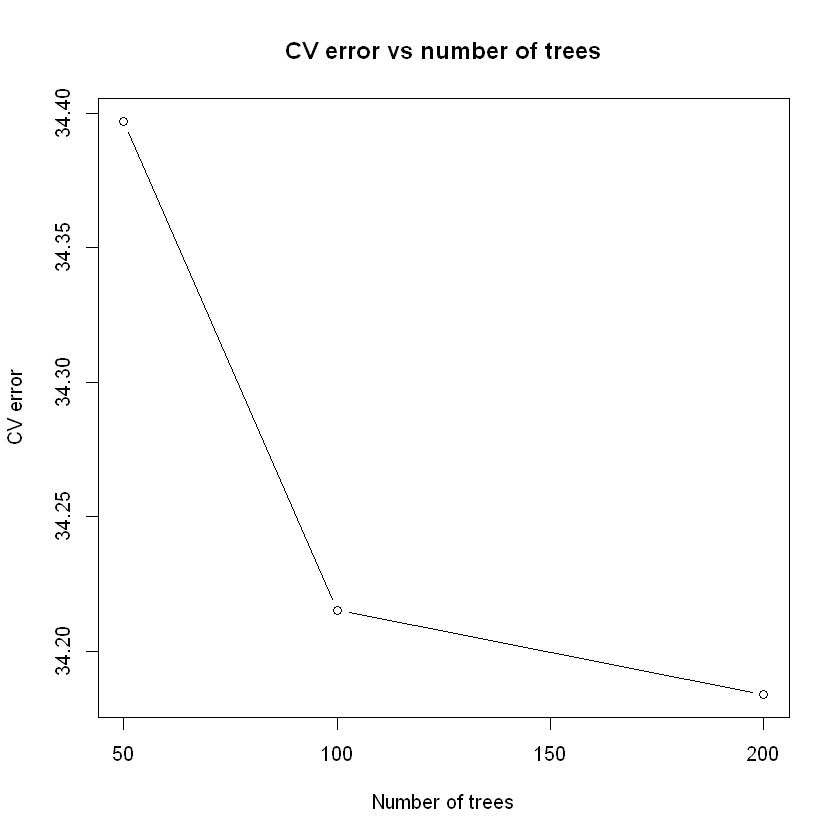

In [39]:
CV_err_ntrees <- apply(CV_err_RF,1, mean)
best_n_trees <- ntree.list[which.min(CV_err_ntrees)]
paste("Best number of trees: ", best_n_trees)
plot(ntree.list, CV_err_ntrees, type = "b", xlab = "Number of trees", ylab = "CV error", main = "CV error vs number of trees")

[1] "Best mtry:  32"

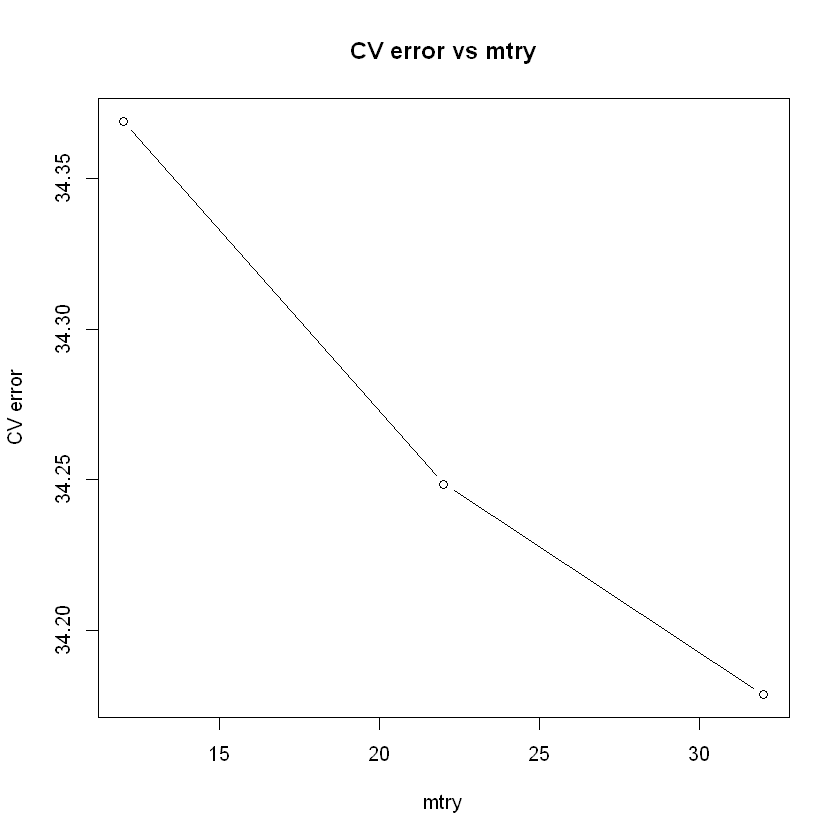

In [38]:
CV_err_mtry <- apply(CV_err_RF,2, mean)
best_mtry <- mtry.list[which.min(CV_err_mtry)]
paste("Best mtry: ", best_mtry)
plot(mtry.list, CV_err_mtry, type = "b", xlab = "mtry", ylab = "CV error", main = "CV error vs mtry")

### 3.2. Deep Neural Network

#### 3.2.1. Usefull functions

In [16]:
# Builds a deep neural network model.
# Parameters:
# - norm: a normalization layer
# - units: a vector of integers representing the number of units in each hidden layer (output layer not included, always 1 unit)
# - activation: the activation function to use in the hidden layers
build_and_compile_model <- function(norm, units, activation) {
  model <- keras_model_sequential() %>% norm()

  for (i in 1:length(units)) {
    model <- model %>% layer_dense(units = units[i], activation = activation)
  }
  model <- model %>% layer_dense(units = 1)

  model %>% compile(
    loss = 'mean_absolute_error',
    optimizer = optimizer_adam(0.001)
  )
  model
}

# Trains a model on the given data.
# Parameters:
# - model: a built and compiled keras model
# - X: the input data
# - Y: the target data
# - epochs: the number of epochs to train the model (default: 100)
train_model <- function(model, X, Y) {
  history <- model %>% fit(
    X, 
    Y,
    epochs = 100,
    verbose = 0
  )
  history
}

#### 3.2.2. Choice of parameters

In [17]:
X_DNN <- X


units_per_layer.list <- c(64, 256, 512)
number_of_layers.list <- c(1, 2)
activation_functions <- c("relu", "tanh", "sigmoid")

n <- ncol(X_DNN)
N <- nrow(X_DNN)

CV_folds <- 2
size_CV <- floor(N/CV_folds)
dimensions <- c(length(units_per_layer.list), length(number_of_layers.list), length(activation_functions))
CV_err_DNN <- array(0, dimensions)
history_matrix <- list()

for (u in 1:length(units_per_layer.list)) {
  for (n in 1:length(number_of_layers.list)) {
      for (a in 1:length(activation_functions)) {
        fold_errors <- numeric(CV_folds)
        for (i in 1:CV_folds) {
          idx_ts <- (((i-1)*size_CV+1):(i*size_CV))
          X_ts <- X_DNN[idx_ts,]
          Y_ts <- Y[idx_ts,]
          
          idx_tr <- setdiff(1:N, idx_ts)
          X_tr <- X_DNN[idx_tr,]
          Y_tr <- Y[idx_tr,]
          
          X_mRMR_normalizer <- layer_normalization(axis = -1L)
          X_mRMR_normalizer %>% adapt(as.matrix(X_tr))
          
          model <- build_and_compile_model( X_mRMR_normalizer, 
                                            rep(units_per_layer.list[u], 
                                            number_of_layers.list[n]), 
                                            activation_functions[a])
          history <- train_model(model, as.matrix(X_tr), as.matrix(Y_tr))
          
          Y_hat_ts <- predict(model, as.matrix(X_ts))
          
          fold_errors[i] <- sqrt(mean((Y_hat_ts - Y_ts)^2))
        }
        CV_err_DNN[u, n, a] <- mean(fold_errors)
    }
  }
}

print(CV_err_DNN)

, , 1

         [,1]     [,2]
[1,] 35.57687 35.92949
[2,] 35.17479 36.24221
[3,] 34.85016 35.87796

, , 2

         [,1]     [,2]
[1,] 35.49273 36.49245
[2,] 35.04723 35.81309
[3,] 35.63828 35.18430

, , 3

         [,1]     [,2]
[1,] 36.12718 36.60537
[2,] 35.82589 36.34650
[3,] 35.29716 35.83235



[1] "Best number of units:  512"

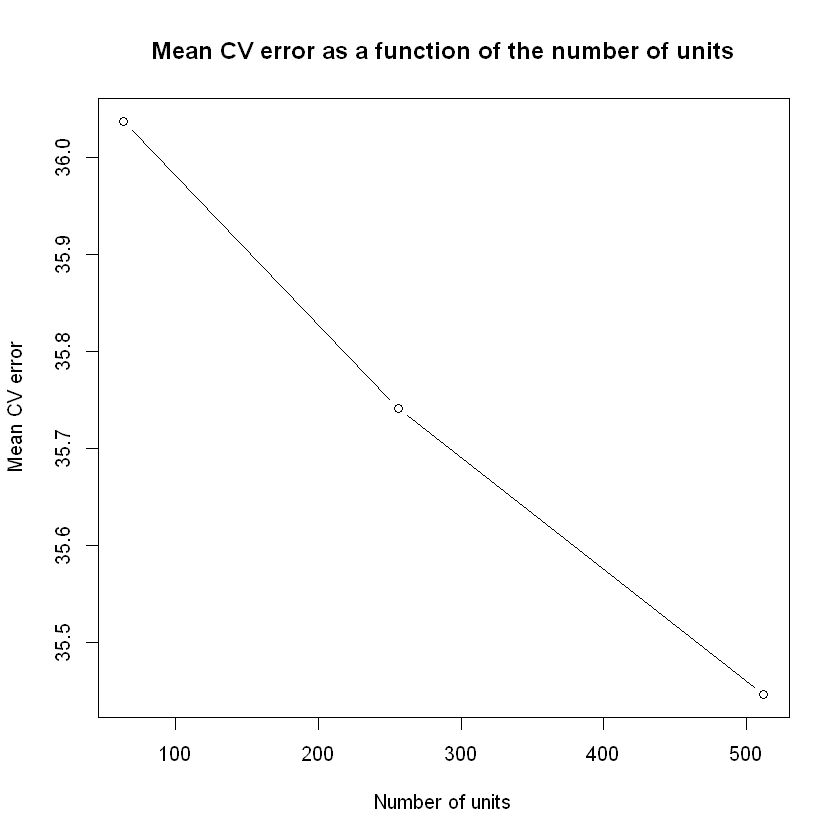

In [37]:
CV_err_units <- apply(CV_err_DNN, 1, mean)
best_units <- units_per_layer.list[which.min(CV_err_units)]
paste("Best number of units: ", best_units)
plot(units_per_layer.list, CV_err_units, type = "b", xlab = "Number of units", ylab = "Mean CV error", main = "Mean CV error as a function of the number of units")

[1] "Best number of layers:  1"

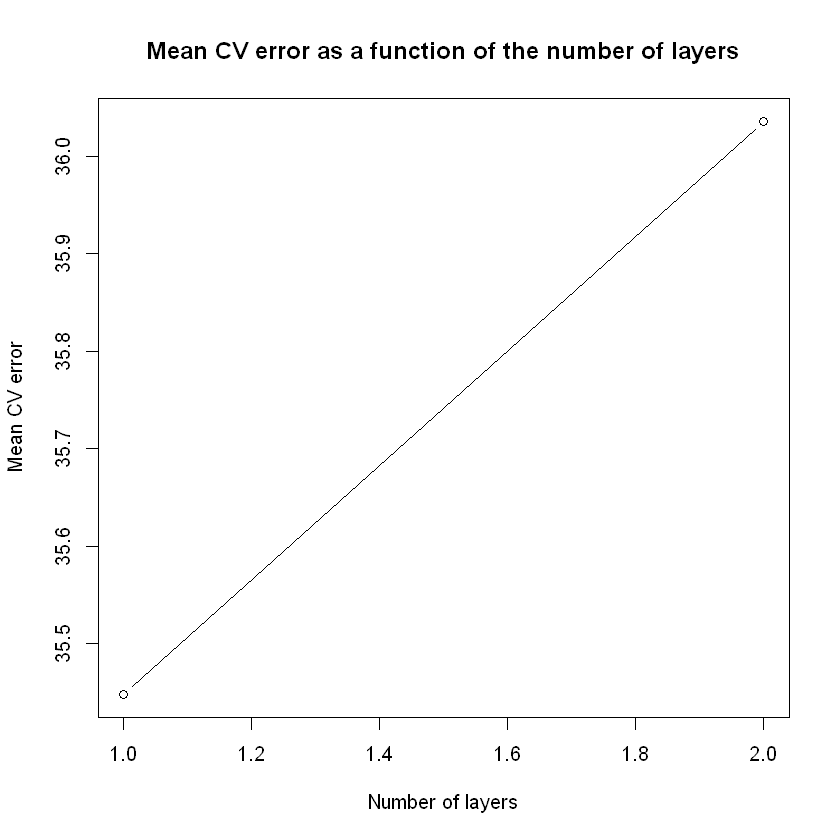

In [36]:
CV_err_layers <- apply(CV_err_DNN, 2, mean)
best_layers <- number_of_layers.list[which.min(CV_err_layers)]
paste("Best number of layers: ", best_layers)
plot(number_of_layers.list, CV_err_layers, type = "b", xlab = "Number of layers", ylab = "Mean CV error", main = "Mean CV error as a function of the number of layers")

[1] "Best activation function:  relu"

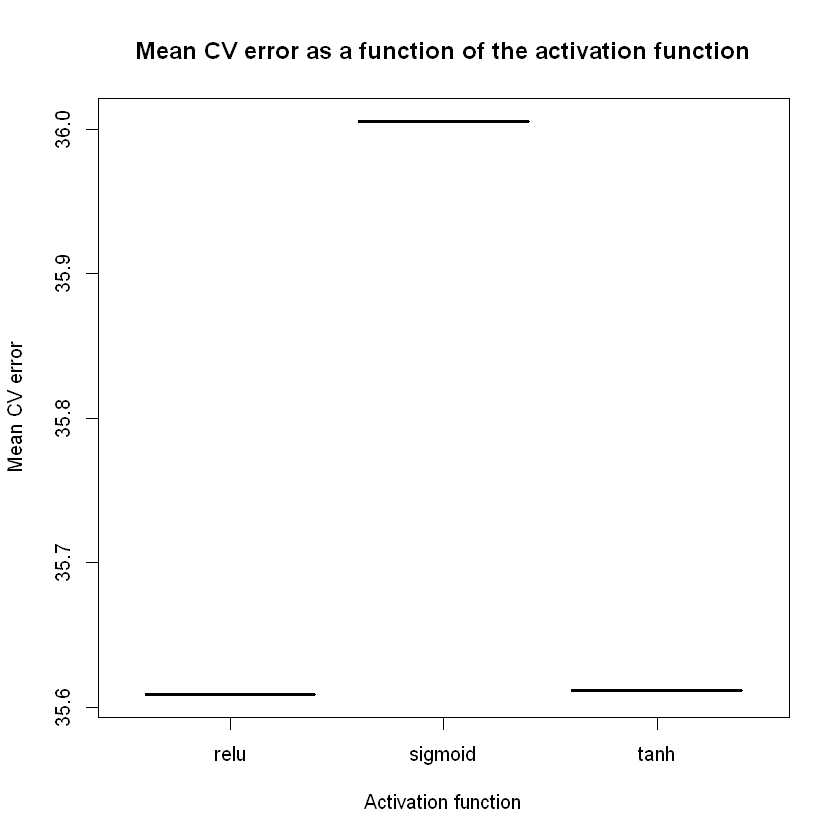

In [25]:
CV_err_activation <- apply(CV_err_DNN, 3, mean)
best_activation <- activation_functions[which.min(CV_err_activation)]
paste("Best activation function: ", best_activation)
activation_functions_factor <- as.factor(activation_functions)
plot(activation_functions_factor, CV_err_activation, type = "l", xlab = "Activation function", ylab = "Mean CV error", main = "Mean CV error as a function of the activation function")

### 3.3. SVM

In [18]:
X_svm <- X

types <- c("eps-regression", "nu-regression")
kernels <- c("linear", "polynomial", "radial", "sigmoid")

n <- ncol(X_svm)
N <- nrow(X_svm)

CV_folds <- 3
size_CV <- floor(N/CV_folds)
CV_err_SVM <- matrix(0, nrow = length(types), ncol = length(kernels))

for (t in 1:length(types)) {
  for (k in 1:length(kernels)) {
    fold_errors <- numeric(CV_folds)
    for (i in 1:CV_folds) {
      idx_ts <- (((i-1)*size_CV+1):(i*size_CV))
      X_ts <- X_svm[idx_ts,]
      Y_ts <- Y[idx_ts,]
      
      idx_tr <- setdiff(1:N, idx_ts)
      X_tr <- X_svm[idx_tr,]
      Y_tr <- Y[idx_tr,]
      train_data <- data.frame(X_tr, target=Y_tr)
      
      model <- svm(target~., data = train_data, type = types[t], kernel = kernels[k])
      
      Y_hat_ts <- predict(model, data.frame(X_ts))
      
      fold_errors[i] <- sqrt(mean((Y_hat_ts - Y_ts)^2))
    }
    CV_err_SVM[t, k] <- mean(fold_errors)
  }
}

print(CV_err_SVM)

         [,1]     [,2]     [,3]     [,4]
[1,] 38.90007 41.77804 34.49429 2371.683
[2,] 38.53199 40.52256 34.39009 2094.296


[1] "Best type:  nu-regression"

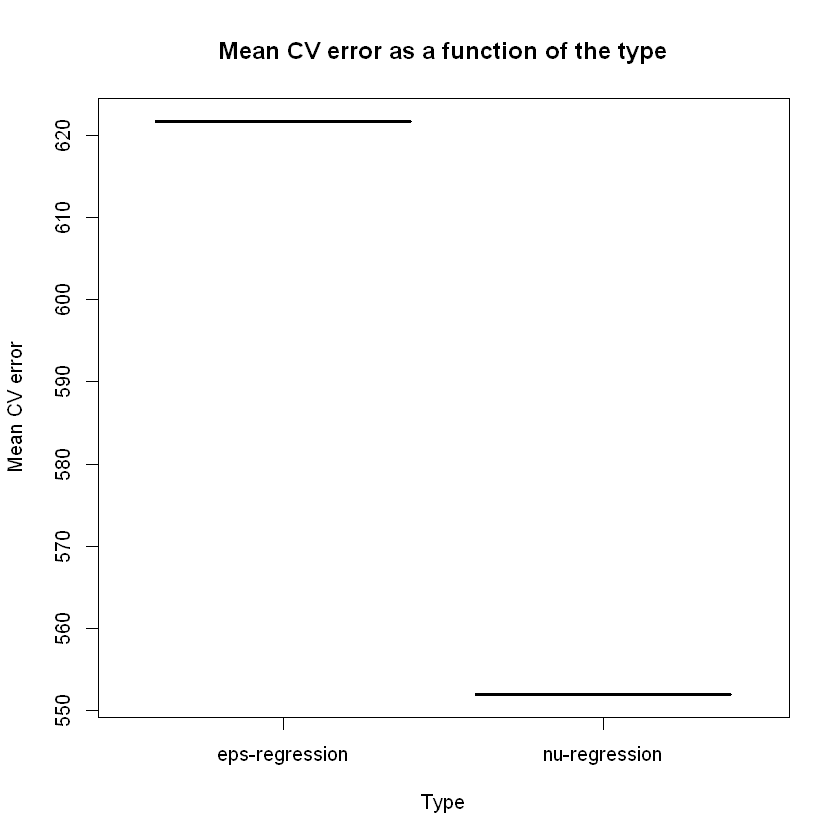

In [26]:
CV_err_types <- apply(CV_err_SVM, 1, mean)
best_type <- types[which.min(CV_err_types)]
paste("Best type: ", best_type)
types_factor <- as.factor(types)
plot(types_factor, CV_err_types, type = "l", xlab = "Type", ylab = "Mean CV error", main = "Mean CV error as a function of the type")

[1] "Best kernel:  radial"

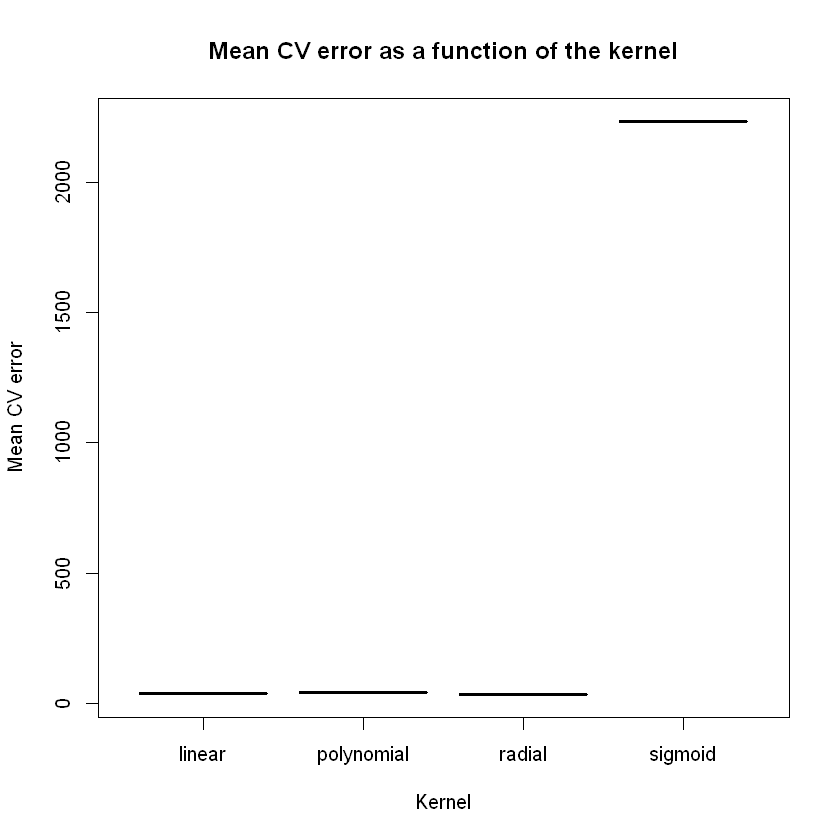

In [27]:
CV_err_kernels <- apply(CV_err_SVM, 2, mean)
best_kernel <- kernels[which.min(CV_err_kernels)]
paste("Best kernel: ", best_kernel)
kernels_factor <- as.factor(kernels)
plot(kernels_factor, CV_err_kernels, type = "l", xlab = "Kernel", ylab = "Mean CV error", main = "Mean CV error as a function of the kernel")

### 3.4. XGBoost

**XGBoost** (e**X**treme **G**radient **Boost**ing) is a gradient boosting algorithm that we choose to use for its effectiveness and speed. It was very usefull for the feature selection part of the project.

The parameters that were optimized are:
- **nrounds**: the number of boosting rounds
- **eta**: the learning rate
- **max_depth**: the maximum depth of the tree
- **min_child_weight**: the minimum sum of instance weight needed in a child

In [19]:
X_XGB <- X
n <- ncol(X_XGB)
N <- nrow(X_XGB)

nrounds.list <- c(50, 100, 200)
eta.list <- c(0.2, 0.3, 0.4)
max_depth.list <- c(5, 6, 7)
min_child_weight.list <- c(0.5, 1, 1.5)

CV_folds <- 5
size_CV <- floor(N / CV_folds)
dimensions <- c(length(nrounds.list), length(eta.list), length(max_depth.list), length(min_child_weight.list))
CV_err_XGB <- array(0, dimensions)

for (nrounds in 1:length(nrounds.list)) {
  for (eta in 1:length(eta.list)) {
    for (max_depth in 1:length(max_depth.list)) {
      for (min_child_weight in 1:length(min_child_weight.list)) {
        fold_errors <- numeric(CV_folds)
        for (i in 1:CV_folds) {
          idx_ts <- (((i-1) * size_CV + 1):(i * size_CV))
          X_ts <- X_XGB[idx_ts, ]
          Y_ts <- Y[idx_ts, ]
          
          idx_tr <- setdiff(1:N, idx_ts)
          X_tr <- X_XGB[idx_tr, ]
          Y_tr <- Y[idx_tr, ]
          
          params <- list(
            eta = eta.list[eta],
            max_depth = max_depth.list[max_depth],
            min_child_weight = min_child_weight.list[min_child_weight]
          ) # List generated by ChatGPT
          
          dtrain <- xgb.DMatrix(data = as.matrix(X_tr), label = Y_tr)
          dtest <- xgb.DMatrix(data = as.matrix(X_ts), label = Y_ts)

          model <- xgb.train(
            params = params,
            data = dtrain,
            nrounds = nrounds.list[nrounds],
            watchlist = list(train = dtrain, test = dtest),
            early_stopping_rounds = 10,
            verbose = 0
          )
          
          Y_hat_ts <- predict(model, as.matrix(X_ts))
          
          fold_errors[i] <- sqrt(mean((Y_hat_ts - Y_ts) ^ 2))
        }
        CV_err_XGB[nrounds, eta, max_depth, min_child_weight] <- mean(fold_errors)
      }
    }
  }
}

print(CV_err_XGB)


, , 1, 1

         [,1]     [,2]     [,3]
[1,] 34.46736 34.63482 34.79135
[2,] 34.18990 34.43440 34.71576
[3,] 34.07165 34.36382 34.71576

, , 2, 1

         [,1]     [,2]     [,3]
[1,] 34.26192 34.31067 34.52096
[2,] 33.92568 34.23157 34.48219
[3,] 33.89025 34.22888 34.48219

, , 3, 1

         [,1]     [,2]     [,3]
[1,] 34.13860 34.28133 34.89408
[2,] 33.92966 34.19787 34.89408
[3,] 33.90944 34.19787 34.89408

, , 1, 2

         [,1]     [,2]     [,3]
[1,] 34.46736 34.63482 34.79135
[2,] 34.18990 34.43440 34.71576
[3,] 34.07165 34.36382 34.71576

, , 2, 2

         [,1]     [,2]     [,3]
[1,] 34.26192 34.31067 34.52096
[2,] 33.92568 34.23157 34.48219
[3,] 33.89025 34.22888 34.48219

, , 3, 2

         [,1]     [,2]     [,3]
[1,] 34.13860 34.28133 34.89408
[2,] 33.92966 34.19787 34.89408
[3,] 33.90944 34.19787 34.89408

, , 1, 3

         [,1]     [,2]     [,3]
[1,] 34.53411 34.48079 35.01900
[2,] 34.27074 34.14362 34.82143
[3,] 34.06281 34.10840 34.81938

, , 2, 3

         [,1]    

[1] "Best number of rounds:  200"

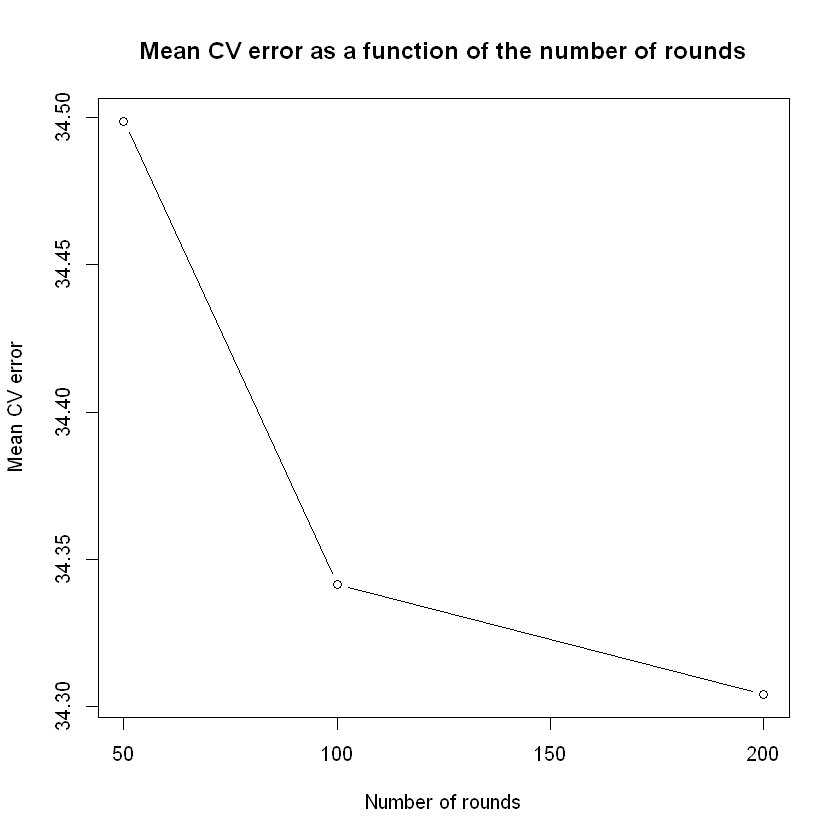

In [35]:
CV_err_nrounds <- apply(CV_err_XGB, 1, mean)
best_nrounds <- nrounds.list[which.min(CV_err_nrounds)]
paste("Best number of rounds: ", best_nrounds)
plot(nrounds.list, CV_err_nrounds, type = "b", xlab = "Number of rounds", ylab = "Mean CV error", main = "Mean CV error as a function of the number of rounds")

[1] "Best eta:  0.2"

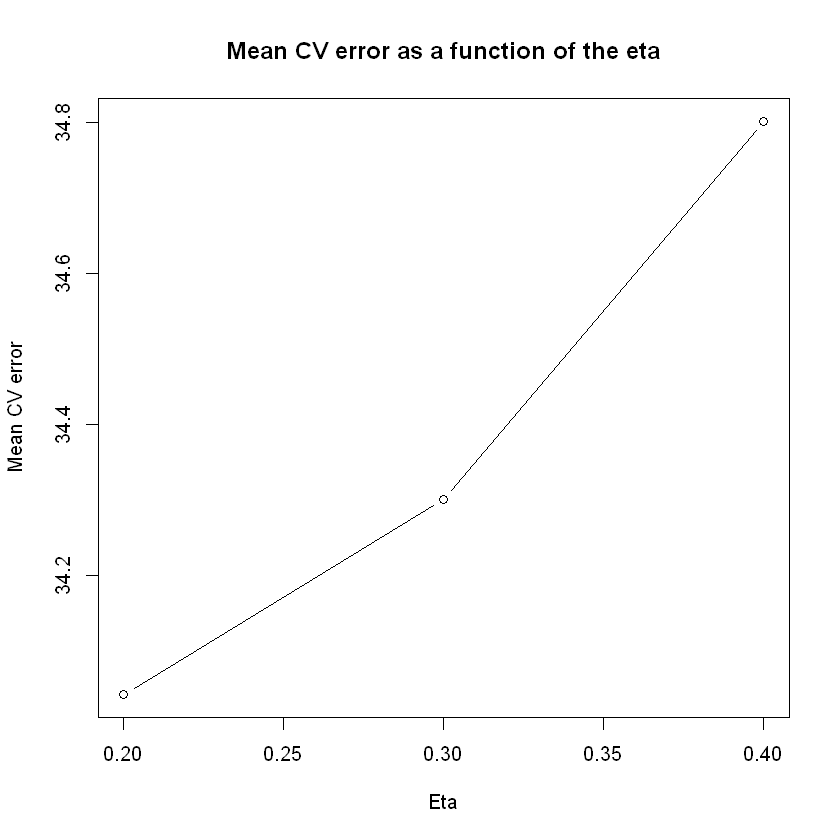

In [34]:
CV_err_eta <- apply(CV_err_XGB, 2, mean)
best_eta <- eta.list[which.min(CV_err_eta)]
paste("Best eta: ", best_eta)
plot(eta.list, CV_err_eta, type = "b", xlab = "Eta", ylab = "Mean CV error", main = "Mean CV error as a function of the eta")

[1] "Best max depth:  6"

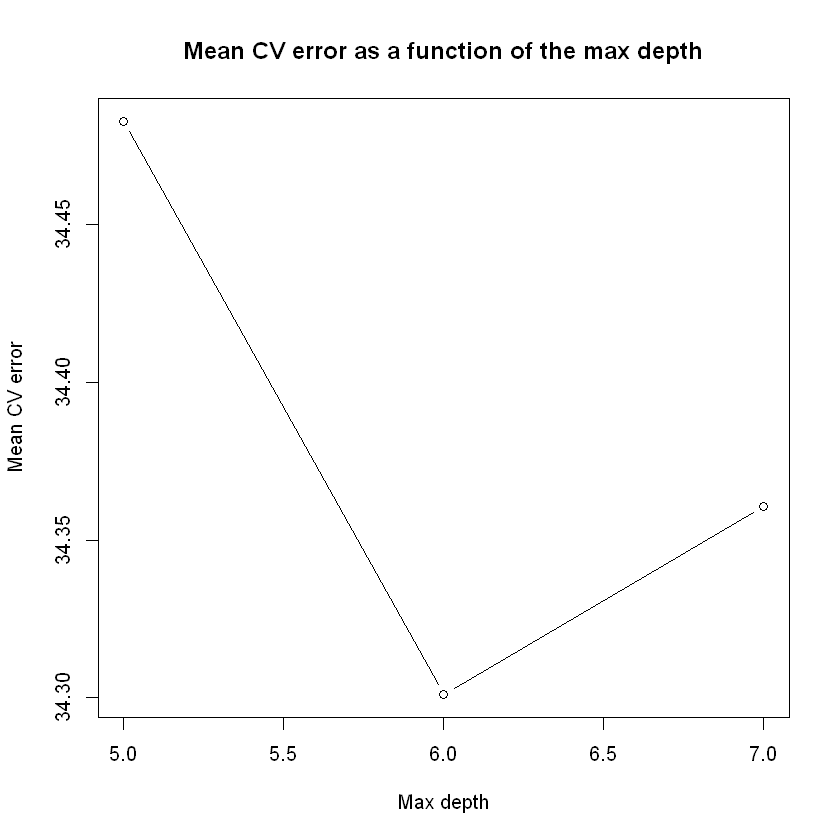

In [33]:
CV_err_max_depth <- apply(CV_err_XGB, 3, mean)
best_max_depth <- max_depth.list[which.min(CV_err_max_depth)]
paste("Best max depth: ", best_max_depth)
plot(max_depth.list, CV_err_max_depth, type = "b", xlab = "Max depth", ylab = "Mean CV error", main = "Mean CV error as a function of the max depth")

[1] "Best min child weight:  0.5"

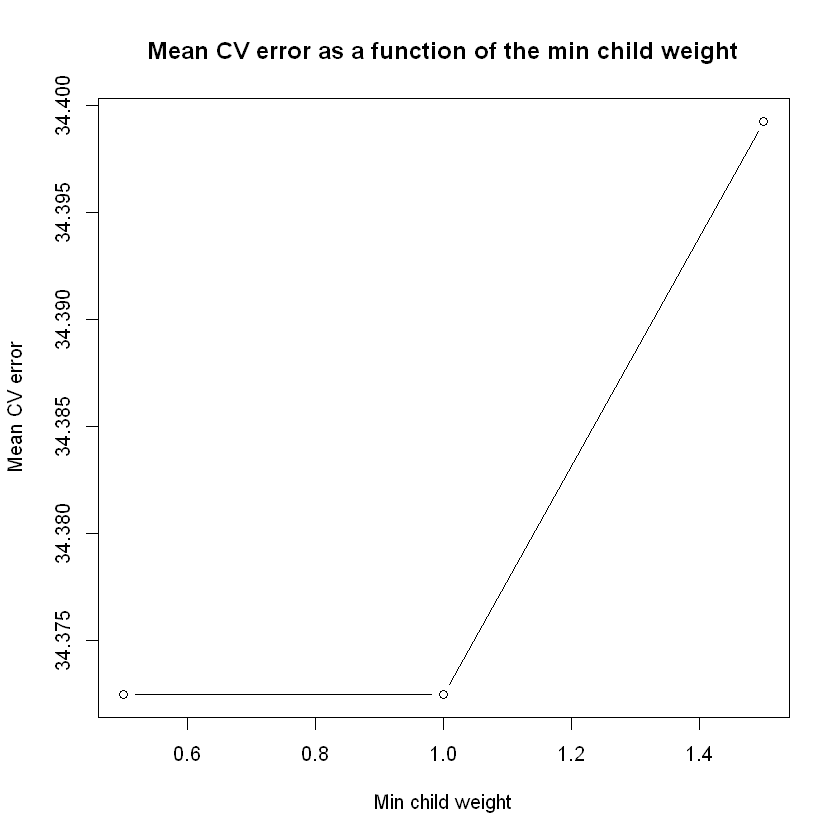

In [32]:
CV_err_min_child_weight <- apply(CV_err_XGB, 4, mean)
best_min_child_weight <- min_child_weight.list[which.min(CV_err_min_child_weight)]
paste("Best min child weight: ", best_min_child_weight)
plot(min_child_weight.list, CV_err_min_child_weight, type = "b", xlab = "Min child weight", ylab = "Mean CV error", main = "Mean CV error as a function of the min child weight")

### 3.5 Best model

Using the best parameters for each model, we train them on all the data and make predictions for the test set. The three models with the highest zindi score are kept for point 4.

In [42]:
X <- X
Y <- Y
n <- ncol(X)
N <- nrow(X)

### test data ###
test_data<-read.csv("test.csv", header = TRUE)

place_idXdate<- data.frame(test_data[, which(names(test_data) == "Place_ID.X.Date")])
#change the name of the column
colnames(place_idXdate)[1] <- "Place_ID.X.Date"


test_data <- dummy_cols(test_data, select_columns = c("Place_ID"))
test_data <- test_data[, which(names(test_data) %in% names(X))]

test_data<-data.frame(apply(test_data,2,replace_na_with_mean_value))

missing_cols <- setdiff(colnames(X), colnames(test_data))

test_data[, missing_cols] <- 0

test_data <- test_data[,colnames(X)] # generated by chatGPT

### Random Forest ###
RF_model <- randomForest(target~., data = data.frame(X, target=Y), ntree = best_n_trees, mtry = best_mtry)

Y_pred <- data.frame(predict(RF_model, data.frame(test_data)))
Y_pred <- cbind(place_idXdate, Y_pred)

write.csv(Y_pred, file = "submission_RF.csv", row.names = FALSE)

# Zindi score: 34.238
### DNN ###
DNN_normalizer <- layer_normalization(axis = -1L)
DNN_normalizer %>% adapt(as.matrix(X))

DNN_model <- build_and_compile_model(DNN_normalizer, rep(best_units, best_layers), best_activation)
history <- train_model(DNN_model, as.matrix(X), as.matrix(Y))

Y_pred <- data.frame(predict(DNN_model, as.matrix(test_data)))
Y_pred <- cbind(place_idXdate, Y_pred)

write.csv(Y_pred, file = "submission_DNN.csv", row.names = FALSE)

# Zindi score: 34.317
### SVM ###
SVM_model <- svm(target~., data = data.frame(X, target=Y), type = best_type, kernel = best_kernel)

Y_pred <- data.frame(predict(SVM_model, data.frame(test_data)))
Y_pred <- cbind(place_idXdate, Y_pred)

write.csv(Y_pred, file = "submission_SVM.csv", row.names = FALSE)

# Zindi score: 34.933
### XGBoost ###
params <- list(
  booster = "gbtree",
  objective = "reg:squarederror",
  eta = best_eta,
  max_depth = best_max_depth,
  min_child_weight = best_min_child_weight
)

dtrain <- xgb.DMatrix(data = as.matrix(X), label = Y[,1])

XGB_model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = best_nrounds,
  verbose = 0
)

Y_pred <- data.frame(predict(XGB_model, as.matrix(test_data)))
Y_pred <- cbind(place_idXdate, Y_pred)

write.csv(Y_pred, file = "submission_XGB.csv", row.names = FALSE)

# Zindi score: 34.199

In [43]:
print(RF_model)
print(DNN_model)
print(SVM_model)
print(XGB_model)


Call:
 randomForest(formula = target ~ ., data = data.frame(X, target = Y),      ntree = best_n_trees, mtry = best_mtry) 
               Type of random forest: regression
                     Number of trees: 200
No. of variables tried at each split: 32

          Mean of squared residuals: 859.8044
                    % Var explained: 60.85


Model: "sequential_36"
_____________________________________________________________________
Layer (type)                   Output Shape               Param #    
normalization_36 (Normalizatio (None, 67)                 135        
_____________________________________________________________________
dense_90 (Dense)               (None, 512)                34816      
_____________________________________________________________________
dense_91 (Dense)               (None, 1)                  513        
Total params: 35,464
Trainable params: 35,329
Non-trainable params: 135
_____________________________________________________________________

Call:
svm(formula = target ~ ., data = data.frame(X, target = Y), type = best_type, 
    kernel = best_kernel)


Parameters:
   SVM-Type:  nu-regression 
 SVM-Kernel:  radial 
       cost:  1 
         nu:  0.5 

Number of Support Vectors:  16799

##### xgb.Booster
raw: 810.3 Kb 
call:
  xgb.train(params = params, data = dtrain, nrounds = bes

## 4. Ensemble

For the final pipeline, we decided to use and ensemble that is basically an average of the predictions of the three best models. The three models are:
- **Random Forest**
- **Deep Neural Network**
- **XGBoost**

The results are better than with the basic models.

Two functions were created to create/train the models and one to make the predictions. 

In [58]:
# Creates and trains an ensemble model.
# Parameters:
# - best_n_trees: the number of trees for the random forest model
# - best_mtry: the number of variables to consider at each split for the random forest model
# - best_units: the number of units in each hidden layer for the DNN model
# - best_layers: the number of hidden layers for the DNN model
# - best_activation: the activation function for the DNN model
# - best_eta: the learning rate for the XGBoost model
# - best_max_depth: the maximum depth of the trees for the XGBoost model
# - best_min_child_weight: the minimum sum of instance weight needed in a child for the XGBoost model
# - best_nrounds: the number of boosting rounds for the XGBoost model
# - X_in: the input data
# - Y_in: the target data
Ensemble_create <- function(best_n_trees, best_mtry, best_units, best_layers, best_activation, best_eta, best_max_depth, best_min_child_weight, best_nrounds, X_in, Y_in) {
  ### Random Forest ###
  if(best_mtry == 0){
      RF_model <- randomForest(target~., data = data.frame(X_in, target=Y_in), ntree = best_n_trees)
  }else{
      RF_model <- randomForest(target~., data = data.frame(X_in, target=Y_in), ntree = best_n_trees, mtry = best_mtry)
  }

  ### DNN ###
  DNN_normalizer <- layer_normalization(axis = -1L)
  DNN_normalizer %>% adapt(as.matrix(X_in))
  
  DNN_model <- build_and_compile_model(DNN_normalizer, rep(best_units, best_layers), best_activation)
  history <- train_model(DNN_model, as.matrix(X_in), as.matrix(Y_in))

  ### XGBoost ###
  params <- list(
    booster = "gbtree",
    objective = "reg:squarederror",
    eta = best_eta,
    max_depth = best_max_depth,
    min_child_weight = best_min_child_weight
  )
  
  dtrain <- xgb.DMatrix(data = as.matrix(X_in), label = Y_in[,1])
  
  XGB_model <- xgb.train(
    params = params,
    data = dtrain,
    nrounds = best_nrounds,
    verbose = 0
  )
  
  list(RF_model, DNN_model, XGB_model)
}

In [45]:
# Predicts the target values using the ensemble model.
# Parameters:
# - models: a list of the trained models
# - X: the input data
Ensemble_predict <- function(models, X) {
  Y_pred <- numeric(nrow(X))
  for (i in 1:length(models)) {
    Y_pred <- Y_pred + predict(models[[i]], as.matrix(X))
  }
  Y_pred <- Y_pred / length(models)
  Y_pred
}

In [46]:
X_train_no_filters <- X
X_train_corr <- X_corr
X_train_mRMR <- X_mRMR
Y_train <- Y

In [47]:
### Ensemble ###
models_no_filters <- Ensemble_create(best_n_trees, best_mtry, best_units, best_layers, best_activation, best_eta, best_max_depth, best_min_child_weight, best_nrounds, X_train_no_filters, Y_train)

In [48]:
models_corr <- Ensemble_create(best_n_trees, best_mtry, best_units, best_layers, best_activation, best_eta, best_max_depth, best_min_child_weight, best_nrounds, X_train_corr, Y_train)

In [49]:
models_mRMR <- Ensemble_create(best_n_trees, best_mtry, best_units, best_layers, best_activation, best_eta, best_max_depth, best_min_child_weight, best_nrounds, X_train_mRMR, Y_train)

In [50]:
test_data<-read.csv("test.csv", header = TRUE)

place_idXdate<- data.frame(test_data[, which(names(test_data) == "Place_ID.X.Date")])
colnames(place_idXdate)[1] <- "Place_ID.X.Date"


test_data <- dummy_cols(test_data, select_columns = c("Place_ID"))
test_data_no_filters <- test_data[, which(names(test_data) %in% names(X_train_no_filters))]
test_data_corr <- test_data[, which(names(test_data) %in% names(X_train_corr))]
test_data_mRMR <- test_data[, which(names(test_data) %in% names(X_train_mRMR))]

test_data_no_filters<-data.frame(apply(test_data_no_filters,2,replace_na_with_mean_value))
test_data_corr<-data.frame(apply(test_data_corr,2,replace_na_with_mean_value))
test_data_mRMR<-data.frame(apply(test_data_mRMR,2,replace_na_with_mean_value))

missing_cols_no_filters <- setdiff(colnames(X_train_no_filters), colnames(test_data_no_filters))
missing_cols_corr <- setdiff(colnames(X_train_corr), colnames(test_data_corr))
missing_cols_mRMR <- setdiff(colnames(X_train_mRMR), colnames(test_data_mRMR))

test_data_no_filters[, missing_cols_no_filters] <- 0
test_data_corr[, missing_cols_corr] <- 0
test_data_mRMR[, missing_cols_mRMR] <- 0

test_data_no_filters <- test_data_no_filters[,colnames(X_train_no_filters)] # generated by chatGPT
test_data_corr <- test_data_corr[,colnames(X_train_corr)]
test_data_mRMR <- test_data_mRMR[,colnames(X_train_mRMR)]

In [51]:
Y_pred_no_filters <- Ensemble_predict(models_no_filters, test_data_no_filters)
Y_pred_corr <- Ensemble_predict(models_corr, test_data_corr)
Y_pred_mRMR <- Ensemble_predict(models_mRMR, test_data_mRMR)

output_no_filters <- data.frame(Place_ID_X_Date=place_idXdate,target=Y_pred_no_filters)
output_corr <- data.frame(Place_ID_X_Date=place_idXdate,target=Y_pred_corr)
output_mRMR <- data.frame(Place_ID_X_Date=place_idXdate,target=Y_pred_mRMR)

write.csv(output_no_filters, "submission_ensemble_no_filters.csv", row.names = FALSE) #Zindi score: 33.136
write.csv(output_corr, "submission_ensemble_corr.csv", row.names = FALSE) #Zindi score: 33.297
write.csv(output_mRMR, "submission_ensemble_mRMR.csv", row.names = FALSE) #Zindi score: 33.165

## 5. Top 10 features

In order to rand the top 10 features we use the mRMR feature selection technique to extract the top 10 features. Then using an estimation of the conditional entropy we calculate the mutual information between the target variable and the features.

We use the best model from the previous steps (e.g. Ensemble of (Random Forest, Deep Neural Network, XGBoost)) to do the estimation.

In [53]:
X_10 <- X_mRMR[,1:10]

### 5.1. Conditional Entropy Estimation

\begin{equation}
H(Y|X) 
\end{equation}

In [59]:
n <- ncol(X_10)
N <- nrow(X_10)

CV_folds <- 10
size_CV <- floor(N/CV_folds)

n_trees <- 30 # Set to 30 to make the computation faster
mtry <- 0 # Set to 0 to use the default value

fold_errors <- numeric(CV_folds)
for (i in 1:CV_folds) {
  idx_ts <- (((i-1)*size_CV+1):(i*size_CV))
  X_ts <- X_10[idx_ts,]
  Y_ts <- Y[idx_ts,]
  
  idx_tr <- setdiff(1:N, idx_ts)
  X_tr <- X_10[idx_tr,]
  Y_tr <- data.frame(target=Y[idx_tr,])

  models <- Ensemble_create(n_trees, mtry, best_units, best_layers, best_activation, best_eta, best_max_depth, best_min_child_weight, best_nrounds, X_tr, Y_tr)
  
  Y_pred <- Ensemble_predict(models, X_ts)
  
  fold_errors[i] <- sqrt(mean((Y_pred - Y_ts)^2))
}
H.X <- mean(fold_errors)

In [60]:
H.X

[1] 35.45803

### 5.2 Conditional Entropy of Variable i Estimation

\begin{equation}
H(y|X^{-i}) 
\end{equation}

In [65]:
H.X_i <- numeric(10)

CV_folds <- 2

for (x_i in 1:10){
    X_10_i <- X_10[,-c(x_i)]
    fold_errors <- numeric(CV_folds)
    for (i in 1:CV_folds) {
      idx_ts <- (((i-1)*size_CV+1):(i*size_CV))
      X_ts <- X_10_i[idx_ts,]
      Y_ts <- Y[idx_ts,]
      
      idx_tr <- setdiff(1:N, idx_ts)
      X_tr <- X_10_i[idx_tr,]
      Y_tr <- data.frame(target=Y[idx_tr,])
      
      models <- Ensemble_create(n_trees, mtry, best_units, best_layers, best_activation, best_eta, best_max_depth, best_min_child_weight, best_nrounds, X_tr, Y_tr)
      
      Y_pred <- Ensemble_predict(models, X_ts)
      
      fold_errors[i] <- sqrt(mean((Y_pred - Y_ts)^2))
    }
    H.X_i[x_i] <- mean(fold_errors)
}

[1] 37.45666 37.01265 36.76190 38.46794 36.63938 36.07045 36.53055 36.23036
 [9] 36.65080 36.35255

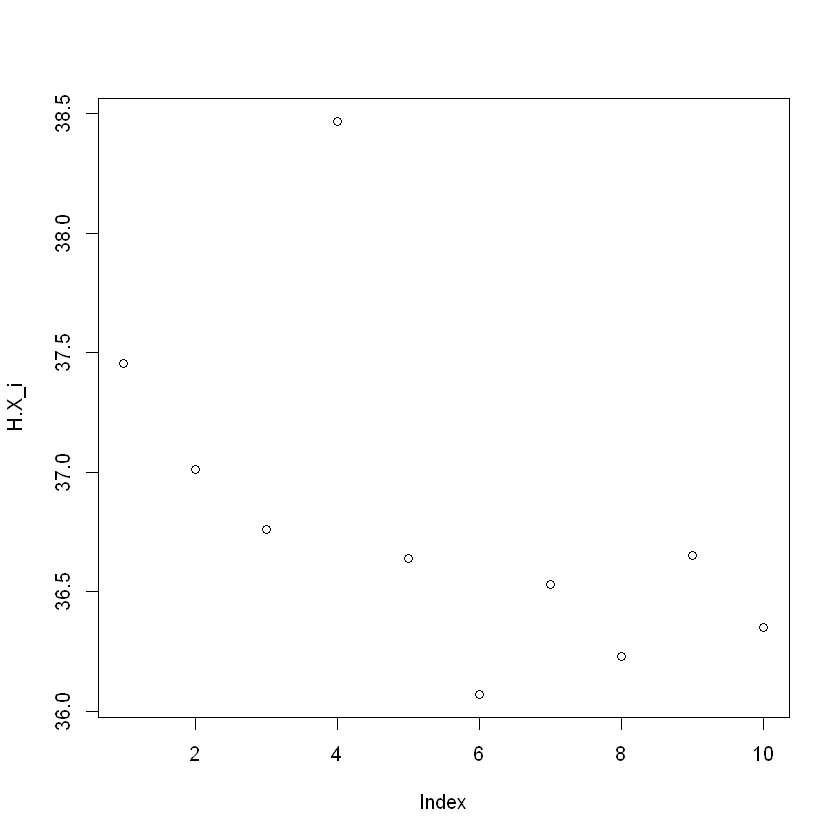

In [66]:
H.X_i
plot(H.X_i)

### 5.3. Mutual information Estimation

\begin{equation}
I(x_i;y|X^{-i}) = H(y|X^{-i}) - H(y|X)
\end{equation}

In [67]:
I.x_i <- H.X_i - H.X 

I.x_i

[1] 1.9986394 1.5546253 1.3038774 3.0099145 1.1813565 0.6124294 1.0725285
 [8] 0.7723353 1.1927763 0.8945274

In [72]:
I.x_i_sorted_indices <- sort(I.x_i, decreasing = TRUE, index.return = TRUE)$ix

I.x_i_sorted_indices
colnames(X_10)[I.x_i_sorted_indices]

[1]  4  1  2  3  9  5  7 10  8  6

[1] "L3_AER_AI_sensor_altitude"                      
 [2] "L3_CO_CO_column_number_density"                 
 [3] "L3_NO2_NO2_slant_column_number_density"         
 [4] "L3_HCHO_tropospheric_HCHO_column_number_density"
 [5] "L3_CLOUD_cloud_top_pressure"                    
 [6] "L3_SO2_absorbing_aerosol_index"                 
 [7] "L3_CLOUD_cloud_optical_depth"                   
 [8] "L3_CO_sensor_azimuth_angle"                     
 [9] "L3_SO2_SO2_column_number_density"               
[10] "u_component_of_wind_10m_above_ground"